<a href="https://colab.research.google.com/github/AleCupSound/SelectedTopicsInMusicAndAcousticsEngineering/blob/main/Lab_1_students.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Lab 1** for the course of *Selected Topics in Music and Acoustic Engineering* :

***Machine Learning for Audio and Acoustic Engineering***
---

* Student 1: Alessandro Cupini
* Student 2: Andrea Casati

# **Before you start**

*   Go to "*File*" --> "*Save a copy in Drive*"
*   Open that copy (might open automatically)
*   Then continue below


**Import libraries**

* We need a number of libraries. Import them once to use throughout the document.

In [ ]:
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8")
import librosa, librosa.display
import IPython

# **Lab 1: Basic Audio Processing in Python**

Python is a general-purpose programming language that is popular and easy to use. For new programmers, it is a great choice as a first programming language. In fact, more and more university CS departments are centering their introductory courses around Python.


#### **The Python Tutorial**

If you are new to Python, you can follow this [Python Tutorial](https://docs.python.org/3.8/tutorial/index.html).

For the purposes of this course, be sure you understand the following sections:

Section 3: *An Informal Introduction to Python*

*   numbers: int, float
*   strings
*   lists

Section 4: *More Control Flow Tools*

*   if statements
*   for statements
*   range
*   functions

Section 5: *Data Structures*

*   list comprehensions
*   tuples
*   dictionaries
*   looping techniques


Other resources:

*   [The Hitchhiker's Guide to Python](http://docs.python-guide.org/en/latest/)
*   [SciPy Lecture Notes](http://www.scipy-lectures.org/)
*   [SciPy Lecture Notes](http://www.scipy-lectures.org/)
*   [learnpython.org](https://www.learnpython.org/)


### **Exercise 1**: Basic operations with arrays

Use numpy to do the following array operations:

* Create a row vector v1: $[1,\, 2,\, 3]$ with shape (1,3)

In [ ]:
v1 = np.array([1, 2, 3]).reshape(1, 3)
print(v1.shape)

(1, 3)


Expected output:
```
(1, 3)
```

* Create a column vector v2:  $[1,\, 2,\, 3]^T$

In [ ]:
v2 = np.array([1, 2, 3]).reshape(3, 1)
print(v2.shape)

(3, 1)


Expected output:
```
(3, 1)
```

* Create a matrix M of 3 x 3 of random integer elements:

In [ ]:
M = np.random.randint(0, 10, size=(3, 3))
print(M)

[[8 8 5]
 [0 2 8]
 [6 7 9]]


* Show the first row of M:

In [ ]:
print(M[0, :])

[8 8 5]


* Show the first column of M:

In [ ]:
print(M[:, 0])

[8 0 6]


* Perform the matrix product v2 times v1:

In [ ]:
result_v2_v1 = v2 @ v1
print(result_v2_v1)

[[1 2 3]
 [2 4 6]
 [3 6 9]]


* Perform the matrix product v1 times v2:

In [ ]:
result_v1_v2 = v1 @ v2
print(result_v1_v2)

[[14]]


* Perform the element-wise multiplication of v2 and v1, with result having the shape of v2:

In [ ]:
result_v2_elemwise = v2 * v1.T
print(result_v2_elemwise)

[[1]
 [4]
 [9]]


* Perform the element-wise multiplication of v1 and v2, with result having the shape of v1:

In [ ]:
result_v1_elemwise = v1 * v2.T
print(result_v1_elemwise)

[[1 4 9]]


* Generate an array of 20 equally-spaced numbers between 0 and 10:

In [ ]:
arr_linspace = np.linspace(0, 10, 20)
print(arr_linspace)

[ 0.          0.52631579  1.05263158  1.57894737  2.10526316  2.63157895
  3.15789474  3.68421053  4.21052632  4.73684211  5.26315789  5.78947368
  6.31578947  6.84210526  7.36842105  7.89473684  8.42105263  8.94736842
  9.47368421 10.        ]


Expected output:
```
[ 0.          0.52631579  1.05263158  1.57894737  2.10526316  2.63157895
  3.15789474  3.68421053  4.21052632  4.73684211  5.26315789  5.78947368
  6.31578947  6.84210526  7.36842105  7.89473684  8.42105263  8.94736842
  9.47368421 10.        ]
```

* Generate an array of numbers going from 0 to 1.5 in steps of 0.2:

In [ ]:
arr_arange = np.arange(0, 1.5, 0.2)
print(np.array_repr(arr_arange))

array([0. , 0.2, 0.4, 0.6, 0.8, 1. , 1.2, 1.4])


Expected output:
```
array([0. , 0.2, 0.4, 0.6, 0.8, 1. , 1.2, 1.4])
```

* Generate an array of 13 logarithmically-spaced numbers between 1 and 2 (both included) using the numpy function logspace()

In [ ]:
arr_logspace = np.logspace(0, 1, 13, base = 2)
print(np.array_repr(arr_logspace))

array([1.        , 1.05946309, 1.12246205, 1.18920712, 1.25992105,
       1.33483985, 1.41421356, 1.49830708, 1.58740105, 1.68179283,
       1.78179744, 1.88774863, 2.        ])


Expected output:
```
array([1.        , 1.05946309, 1.12246205, 1.18920712, 1.25992105,
       1.33483985, 1.41421356, 1.49830708, 1.58740105, 1.68179283,
       1.78179744, 1.88774863, 2.        ])
```

* Generate the same array of 13 logarithmically-spaced numbers using fractional powers of 2 (i.e. ```2**...```):


In [ ]:
arr_logspace_fractional = 2**np.linspace(0, 1, 13)
print(np.array_repr(arr_logspace_fractional))

array([1.        , 1.05946309, 1.12246205, 1.18920712, 1.25992105,
       1.33483985, 1.41421356, 1.49830708, 1.58740105, 1.68179283,
       1.78179744, 1.88774863, 2.        ])


Expected output:
```
array([1.        , 1.05946309, 1.12246205, 1.18920712, 1.25992105,
       1.33483985, 1.41421356, 1.49830708, 1.58740105, 1.68179283,
       1.78179744, 1.88774863, 2.        ])
```

The generated array divides logarithmically an octave and can be used to generate fundamental frequencies for the pitches:

Index | 0 | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10 | 11 | 12
---| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | ---
Pitch | A | A# | B | C | C# | D | D# | E | F | F# | G | G# | A$_2$  



* Use as a starting fundamental frequency, the one corresponding to A (440 Hz), and generate an array with the fundamental frequencies of each pitch:

In [ ]:
fundamental_frequencies = 440 * arr_logspace_fractional
print(fundamental_frequencies)

[440.         466.16376152 493.88330126 523.2511306  554.36526195
 587.32953583 622.25396744 659.25511383 698.45646287 739.98884542
 783.99087196 830.60939516 880.        ]


Expected output:
```
[440.         466.16376152 493.88330126 523.2511306  554.36526195
 587.32953583 622.25396744 659.25511383 698.45646287 739.98884542
 783.99087196 830.60939516 880.        ]
```

### **Exercise 2**: Generation of notes

Assume a sampling frequency of fs = 16000 Hz, and generate a time vector with sampling instants between 0 s and 2 s:

In [ ]:
fs = 16000
t = np.arange(0, 2, 1/fs)
print(t)

[0.0000000e+00 6.2500000e-05 1.2500000e-04 ... 1.9998125e+00 1.9998750e+00
 1.9999375e+00]


Expected output:
```
[0.0000000e+00 6.2500000e-05 1.2500000e-04 ... 1.9998125e+00 1.9998750e+00
 1.9999375e+00]
```

### Tasks:
* Generate an array containing the envelope shape:

\begin{equation}
  a(t) = Ae^{-t/\tau}
\end{equation}

with $\tau = 0.4$, $A=0.5$ and $t$ corresponding to a given time instant:

In [ ]:
fs = 16000
t = np.arange(0, 2, 1/fs)

tau = 0.4
A = 0.5
a = A * np.exp(-t / tau)
print(f'a = {a}')

a = [0.5        0.49992188 0.49984377 ... 0.00337055 0.00337003 0.0033695 ]


Expected output:
```
a = [0.5        0.49992188 0.49984377 ... 0.00337055 0.00337003 0.0033695 ]
```

* Plot the envelope using Matplotlib:

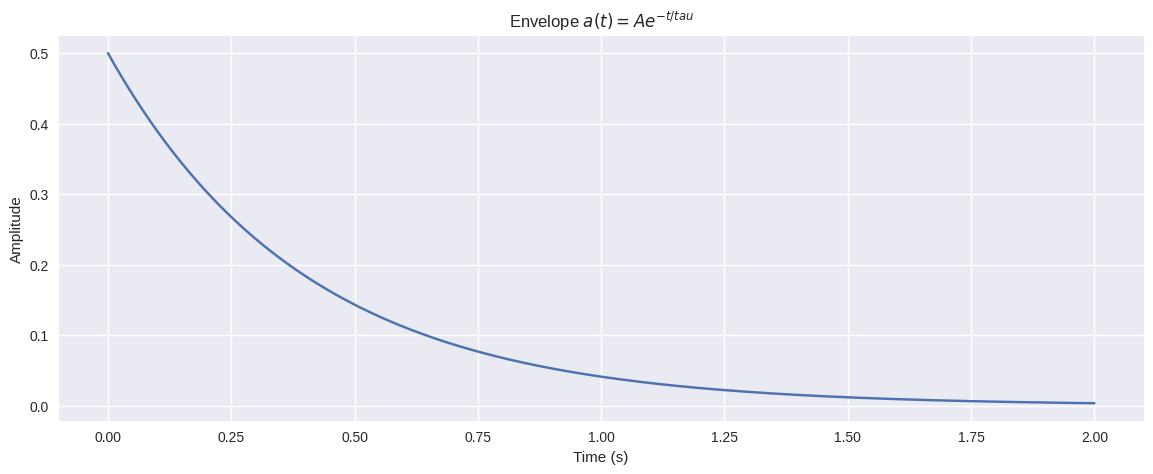

In [ ]:
plt.figure(figsize=(14,5))
plt.plot(t, a)
plt.title('Envelope $a(t) = A e^{-t/tau}$')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)

* Generate a sawtooth wave by using ```scipy.signal``` to generates notes with the model

\begin{equation}
  x(t) = a(t) \textrm{sawtooth}(2\pi f_k t)
\end{equation}

where $a(t)$ is the envelope (see above) and $f_k$ the fundamental frequencies of the $k$-th pitch as in the table of Exercise 1.

Generate note signals for pitches A, C#, E and A$_2$:

In [ ]:
f_A = fundamental_frequencies[0]
f_C_sharp = fundamental_frequencies[4]
f_E = fundamental_frequencies[7]
f_A2 = fundamental_frequencies[12]

x_A = a * signal.sawtooth(2 * np.pi * f_A * t)
x_C_sharp = a * signal.sawtooth(2 * np.pi * f_C_sharp * t)
x_E = a * signal.sawtooth(2 * np.pi * f_E * t)
x_A2 = a * signal.sawtooth(2 * np.pi * f_A2 * t)

* Listen to each of the notes by using ``IPython.display.display(IPython.display.Audio(x, rate=fs))``

In [ ]:
IPython.display.display(IPython.display.Audio(x_A, rate=fs))
IPython.display.display(IPython.display.Audio(x_C_sharp, rate=fs))
IPython.display.display(IPython.display.Audio(x_E, rate=fs))
IPython.display.display(IPython.display.Audio(x_A2, rate=fs))

* Generate a vector arpegio by concatenating the four notes:

In [ ]:
arpegio = np.concatenate((x_A, x_C_sharp, x_E, x_A2))
IPython.display.display(IPython.display.Audio(arpegio, rate=fs))

* Generate a vector chord made by summing up the four notes and dividing
them by 4 to avoid clipping:

In [ ]:
chord = (x_A + x_C_sharp + x_E + x_A2) / 4
IPython.display.display(IPython.display.Audio(chord, rate=fs))

### **Exercise 3**: STFT Representation

Now let's download a speech signal using the wget command. Then, we are going to read it with using ```librosa.load``` and show its sampling rate and duration.

Note 1: The audio file can be also downloaded and imported into you colab space manually.

Note 2: By default, ```librosa.load``` resample the input signal to 22050Hz. If we want to keep the original sampling frequency, then use ```sr=None```.

In [ ]:
!pip install wget
!wget -P sample_data/ https://www.voiptroubleshooter.com/open_speech/american/OSR_us_000_0010_8k.wav

  Preparing metadata (setup.py) ... done
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9655 sha256=820bc537f797b140ec4b2f6bef9563ad41051c0e6bdfd03ebb36a2b656402e14
  Stored in directory: /root/.cache/pip/wheels/01/46/3b/e29ffbe4ebe614ff224bad40fc6a5773a67a163251585a13a9
Successfully built wget
--2026-03-16 15:54:13--  https://www.voiptroubleshooter.com/open_speech/american/OSR_us_000_0010_8k.wav
Resolving www.voiptroubleshooter.com (www.voiptroubleshooter.com)... 162.241.218.124
Connecting to www.voiptroubleshooter.com (www.voiptroubleshooter.com)|162.241.218.124|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 538014 (525K) [audio/x-wav]
Saving to: ‘sample_data/OSR_us_000_0010_8k.wav’

OSR_us_000_0010_8k. 100%[===================>] 525.40K  2.59MB/s    in 0.2s    

2026-03-16 15:54:14 (2.59 MB/s) - ‘sample_data/OSR_us_000_0010_8k.wav’ saved [538014/538014]



In [ ]:
signal, sample_rate = librosa.load('sample_data/OSR_us_000_0010_8k.wav', sr=None)
print(f'Sample rate: {sample_rate}')
duration = len(signal) / sample_rate
print(f'Signal duration {duration}')

Sample rate: 8000
Signal duration 33.623125


Expected output:
```
Sample rate:  8000
Signal duration 33.623125
```

### Taks:
* Cut the signal to show only the third spoken sentence (from t=7 s to t = 10 s). Represent it with respect to time in seconds.

In [ ]:
plt.figure(figsize=(14,5))
start_time_s = 7
end_time_s = 10

start_sample_index = int(start_time_s * sample_rate)
end_sample_index = int(end_time_s * sample_rate)

print(f'Start sample index: {start_sample_index}')
print(f'End sample index: {end_sample_index}')

Start sample index: 56000
End sample index: 80000


<Figure size 1400x500 with 0 Axes>

* Now listen to the selected audio segment:

In [ ]:
selected_segment = signal[start_sample_index:end_sample_index]
IPython.display.display(IPython.display.Audio(selected_segment, rate=sample_rate))

Create a function "enframe" that takes as input:

*   signal (one-dimensional)
*   frame length (in samples)
*   hop size (in samples)

and returns a matrix where each column stores a frame of the signal. The function should pad the signal with zeroes if necessary.

Here is the pseudocode:



```
FUNCTION enframe(signal, frame_length, hop_size)
    INPUT:
        signal: Array containing the audio signal samples
        frame_length: Integer, the number of samples per frame
        hop_size: Integer, the number of samples to step between frames
    OUTPUT:
        frames: 2D Array where each row is a frame of the signal

    INITIALIZE empty list frames

    CALCULATE total_frames = CEIL((length of signal - frame_length) / hop_size) + 1

    CALCULATE padding_needed = (total_frames - 1) * hop_size + frame_length - length of signal

    IF padding_needed > 0 THEN
        APPEND padding_needed zeros to signal

    FOR i FROM 0 TO total_frames - 1
        START_INDEX = i * hop_size
        END_INDEX = START_INDEX + frame_length

        APPEND signal[START_INDEX:END_INDEX] TO frames

    RETURN frames
END FUNCTION
```

In [ ]:
def enframe(signal, frame_length, hop_size):
    frames = []
    total_frames = int(np.ceil((len(signal) - frame_length) / hop_size)) + 1
    padding_needed = (total_frames - 1) * hop_size + frame_length - len(signal)

    if padding_needed > 0:
        signal = np.pad(signal, (0, padding_needed), mode='constant', constant_values=0)

    for i in range(total_frames):
        start_index = i * hop_size
        end_index = start_index + frame_length
        frames.append(signal[start_index:end_index])

    frames = np.array(frames).T
    return frames


* Divide the signal into frames of length 512, using a hop size of 256 samples. Show the dimensions of the output.

In [ ]:
frame_length= 512
hop_size = 256

frames_matrix = enframe(selected_segment, frame_length, hop_size)
print(f'shape = {frames_matrix.shape}')

shape = (512, 93)


Expected output:
```
shape = (512, 93)
```

* Plot the content of the 10-th frame:

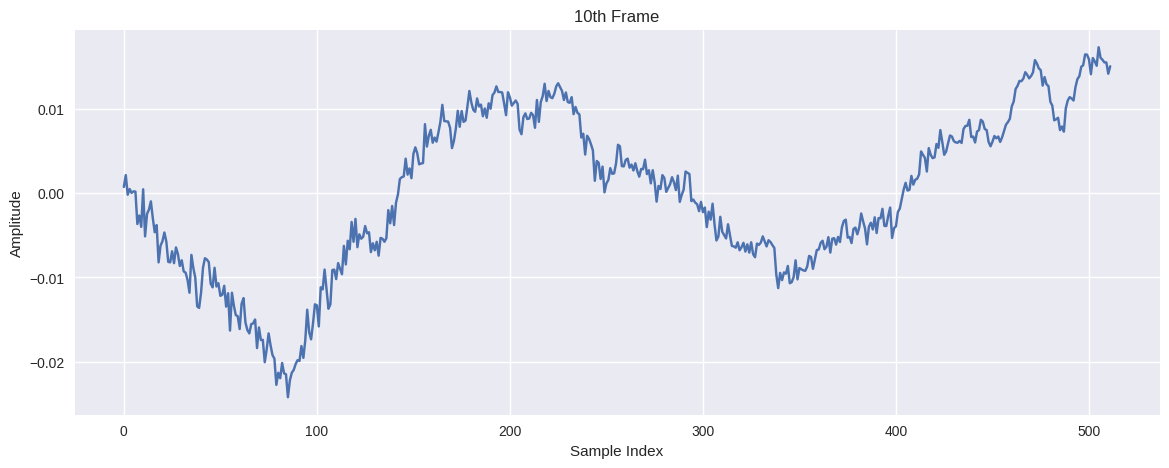

In [ ]:
plt.figure(figsize=(14,5))
frame_10 = frames_matrix[:, 9]
plt.plot(frame_10)
plt.title('10th Frame')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

* Create a Hamming function and apply it to each of your frames:

In [ ]:
winfunc = np.hamming(frame_length)
windowed_frames = frames_matrix * winfunc[:, np.newaxis]
print(f'Shape of windowed_frames: {windowed_frames.shape}')

Shape of windowed_frames: (512, 93)


* Plot again the 10-th frame after having applied your Hamming window:

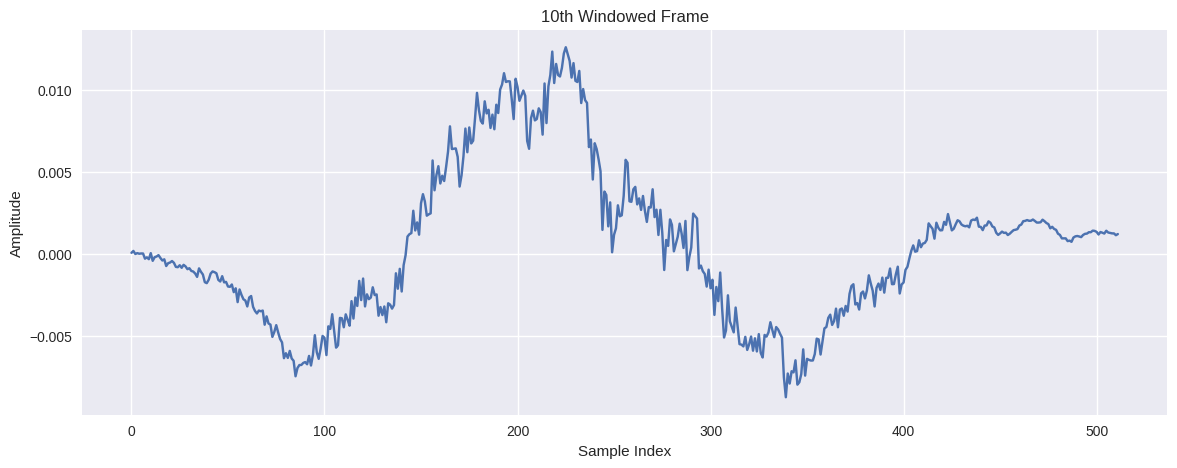

In [ ]:
plt.figure(figsize=(14,5))
windowed_frame_10 = windowed_frames[:, 9]
plt.plot(windowed_frame_10)
plt.title('10th Windowed Frame')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

* Compute the DFT of each column (frame) using numpy's ```rfft()``` function. Use as number of FFT points the same value as window length.

In [ ]:
NFFT = frame_length

X = np.fft.rfft(windowed_frames, n=NFFT, axis=0)
print(f'Shape of X: {X.shape}')

Shape of X: (257, 93)


* Use the following function to represent the result with the indices of each frame and each frequency bin in the horizontal and vertical axes, respectively.



In [ ]:
def show_specgram(X,ratio,limits,cmin):
  '''This function represents matrix X within a figure having the desired
  aspect ratio.
  Input:
    - X: matrix to represent
    - ratio: aspect ratio of axes
    - limits: array with [xmin, xmax, ymax, ymin] (y axis is reversed)
    - cmin: minimum value corresponding to the bottom of the colormap scale.
  Output:
    - figure handle
  '''
  w, h = plt.figaspect(ratio);
  fig = plt.figure(figsize=(w*2, h*2))
  ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
  im = ax.imshow(X, extent = limits, cmap='viridis', interpolation='none')
  xleft, xright = ax.get_xlim()
  ybottom, ytop = ax.get_ylim()
  ax.set_aspect(abs((xright-xleft)/(ybottom-ytop))*ratio)
  ax.invert_yaxis()
  if cmin != None:
    cbar = plt.colorbar(im)
    cbar.mappable.set_clim(cmin, None)
  return ax

* Now let's use the function ```show_spectrogram```to display the log power spectrogram ```(10*np.log10(np.abs(X)**2)``.

Note: User parameters ratio=0.7 and  cmin=-50

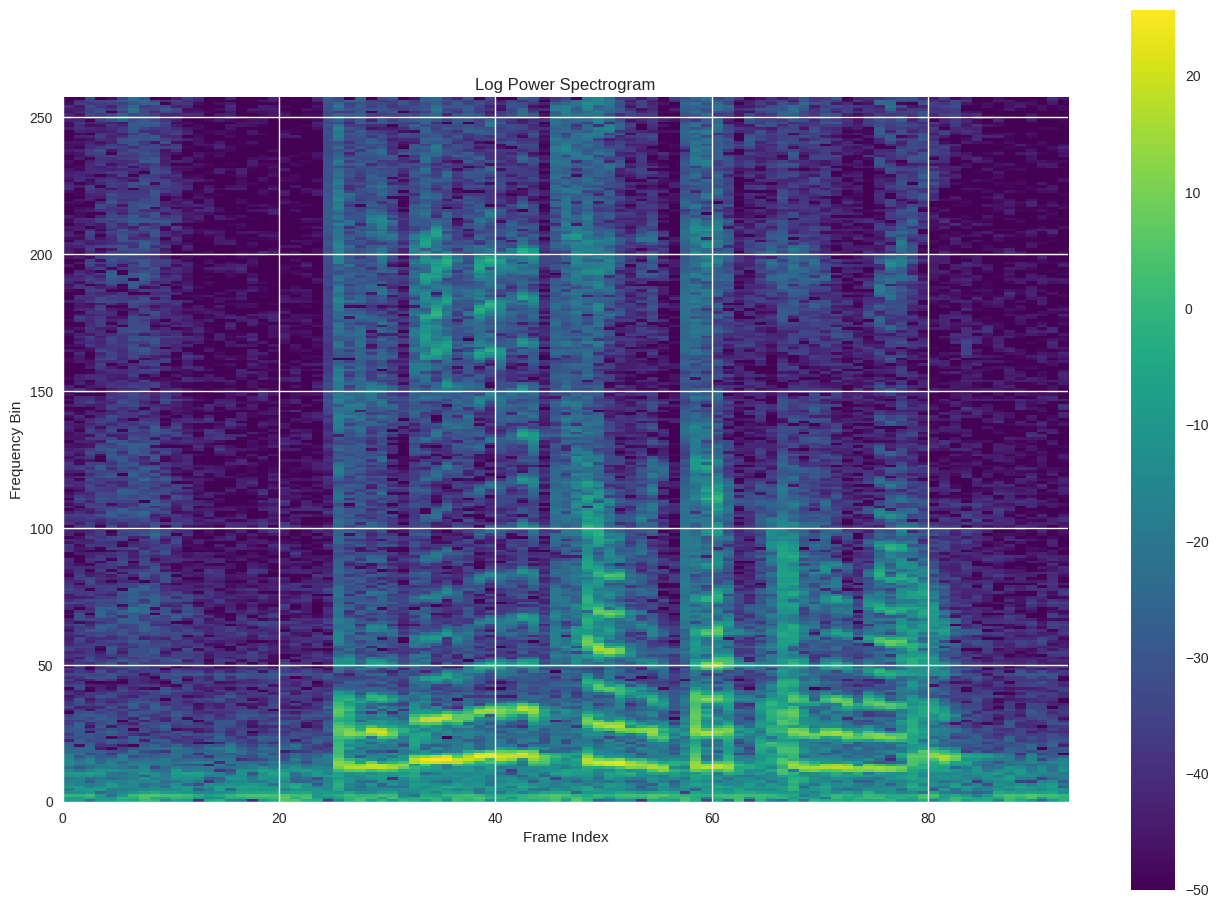

In [ ]:
log_power_spectrogram = 10 * np.log10(np.abs(X)**2)
ax = show_specgram(log_power_spectrogram, ratio=0.7, limits=[0, log_power_spectrogram.shape[1], log_power_spectrogram.shape[0], 0], cmin=-50)

plt.xlabel('Frame Index')
plt.ylabel('Frequency Bin')
plt.title('Log Power Spectrogram')
plt.show()


* Finally, represent again the spectrogram but as a function of the time in seconds and frequency in Hz.

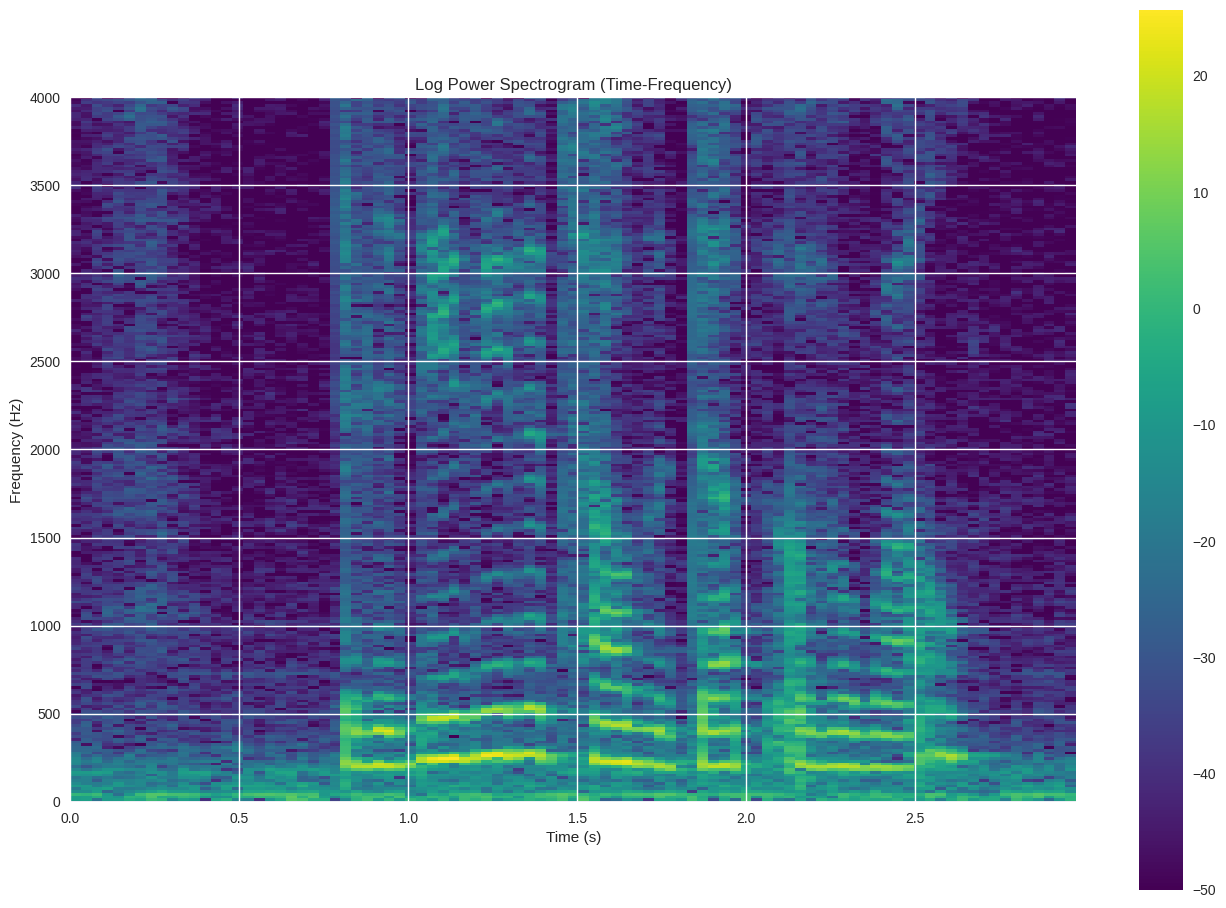

In [ ]:
f_bins = np.linspace(0, sample_rate / 2, NFFT // 2 + 1)
num_frames = log_power_spectrogram.shape[1]
time_seconds = np.arange(0, num_frames) * hop_size / sample_rate

# Limits for show_specgram
time_min = time_seconds[0]
time_max = time_seconds[-1] + (hop_size / sample_rate)
freq_min = f_bins[0]
freq_max = f_bins[-1]

ax = show_specgram(
    log_power_spectrogram,
    ratio=0.7,
    limits=[time_min, time_max, freq_max, freq_min],
    cmin=-50
)

plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.title('Log Power Spectrogram (Time-Frequency)')
plt.show()


### **Exercise 4**: Librosa representations (STFT)

Let's first check the librosa documentation: https://librosa.org/doc/main/generated/librosa.stft.html?highlight=stft#librosa-stft

The most important parameters are:
  - **win_length** - this is the size of our analysis window (in samples)
  - **hop_length** - this is the hop size of our analysis window (in samples), usually this is chosen to be half the window size
  - (**n_fft**) - this is the used "FFT size", which can be bigger than the **win_length** (but should be a power of two, such that the Fast Fourier Transform (FFT) algorithm can be used internally)
  

### Tasks:
* Use librosa to represent the power spectrogram of the signal, as we computed manually in the last exercise.

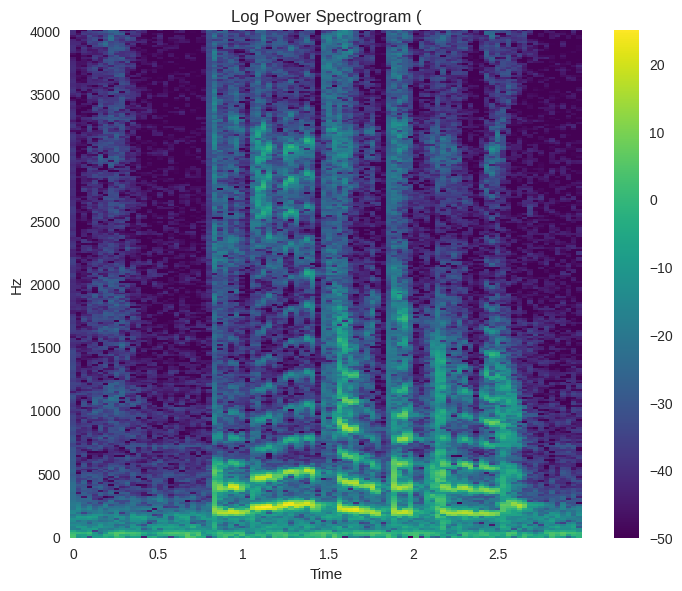

In [ ]:
n_fft_opt = int(2**np.ceil(np.log2(frame_length)))
X_librosa = librosa.stft(y=selected_segment, win_length=frame_length, n_fft=n_fft_opt, hop_length=hop_size)
X_pow_db = librosa.power_to_db(np.abs(X_librosa)**2)

w, h = plt.figaspect(0.8);
plt.figure(figsize=(w*1.2,h*1.2));
librosa.display.specshow(X_pow_db, sr=sample_rate, hop_length=hop_size, x_axis='time', y_axis='hz', fmax=sample_rate/2, cmap='viridis');
plt.clim(-50,None);
plt.colorbar();
plt.title('Log Power Spectrogram (');


* Experiment with different values of frame length and hop size and discuss the results. **vanno scritte le differenze nelle conclusioni dopo i grafici

**Case 1 - Decrease the frame length and hop size to 1/4 of the original value**


frame_length_1: 128
hop_size_1: 64


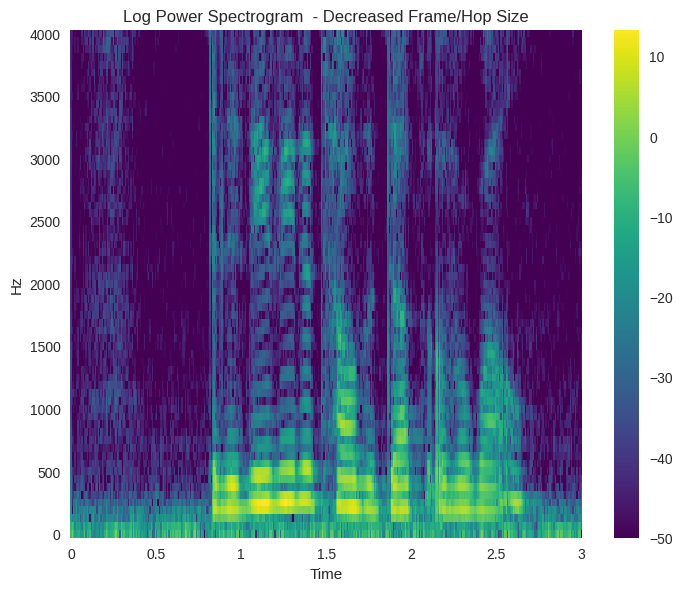

In [ ]:
frame_length_1 = int(frame_length/4);
hop_size_1 = int(hop_size/4);
print("frame_length_1:", frame_length_1)
print("hop_size_1:", hop_size_1)

n_fft_opt_1 = int(2**np.ceil(np.log2(frame_length_1)))
X_librosa_case1 = librosa.stft(y=selected_segment, win_length=frame_length_1, n_fft=n_fft_opt_1, hop_length=hop_size_1)
X_pow_db_case1 = librosa.power_to_db(np.abs(X_librosa_case1)**2)

w, h = plt.figaspect(0.8);
plt.figure(figsize=(w*1.2,h*1.2));
librosa.display.specshow(X_pow_db_case1, sr=sample_rate, hop_length=hop_size_1, x_axis='time', y_axis='hz', fmax=sample_rate/2, cmap='viridis');
plt.clim(-50,None);
plt.colorbar();
plt.title('Log Power Spectrogram  - Decreased Frame/Hop Size');
plt.show()

Conclusions:
In the first case the shorter temporal window leads to a better temporal resolution, allowing for distinction of shorter sound events; but poorer frequency resolution where frequency bands are wider and less defined. The time plot will be more detailed. By decreasing the hop_size, the overlap between frames increases, making the temporal representation denser and visually more continuous.

**Case 2 - Increase the frame length and hop size to x2 of the original values**


frame_length_2: 1024
hop_size_2: 512


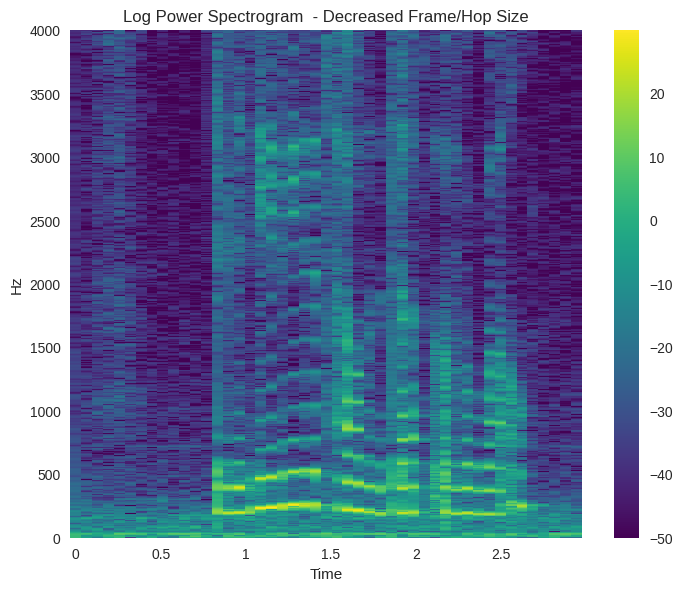

In [ ]:
frame_length_2 = int(frame_length*2);
hop_size_2 = int(hop_size*2);
print("frame_length_2:", frame_length_2)
print("hop_size_2:", hop_size_2)

n_fft_opt_2 = int(2**np.ceil(np.log2(frame_length_2)))
X_librosa_case1 = librosa.stft(y=selected_segment, win_length=frame_length_2, n_fft=frame_length_2, hop_length=hop_size_2)
X_pow_db_case1 = librosa.power_to_db(np.abs(X_librosa_case1)**2)

w, h = plt.figaspect(0.8);
plt.figure(figsize=(w*1.2,h*1.2));
librosa.display.specshow(X_pow_db_case1, sr=sample_rate, hop_length=hop_size_2, x_axis='time', y_axis='hz', fmax=sample_rate/2, cmap='viridis');
plt.clim(-50,None);
plt.colorbar();
plt.title('Log Power Spectrogram  - Decreased Frame/Hop Size');
plt.show()

Conclusions: In the second case the frame length is increased, and a longer temporal window is used. This parameters improve frequency resolution where frequency bands are narrower and more defined but degrades temporal resolution; in fact by increasing the hop_size the overlap between frames is reduced, making temporal representation less dense.

**Case 3 - Increasing the frame length and decreasing the overlapping of frames simultaneously**



frame_length_3: 1024
hop_size_3 1024


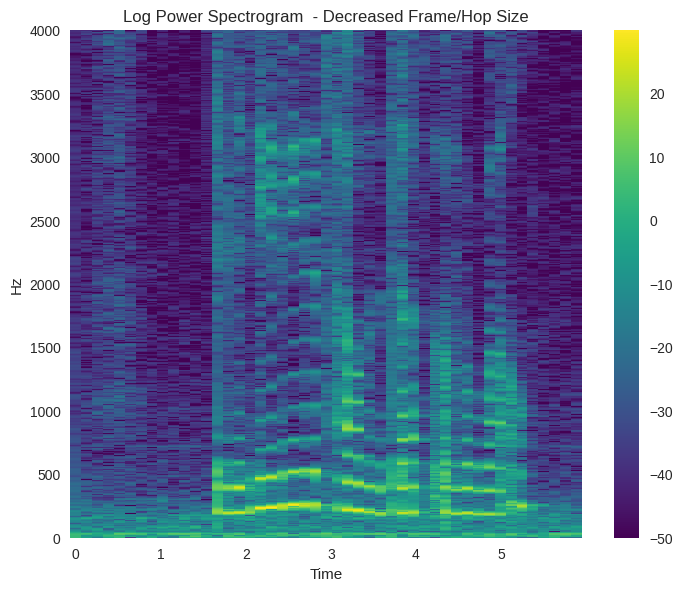

In [ ]:
frame_length_3 = 1024;
hop_size_3 = 1024;
print("frame_length_3:", frame_length_3)
print("hop_size_3", hop_size_3)

n_fft_opt_3 = int(2**np.ceil(np.log2(frame_length_3)))
X_librosa_case1 = librosa.stft(y=selected_segment, win_length=frame_length_3, n_fft=n_fft_opt_3, hop_length=hop_size_2)
X_pow_db_case1 = librosa.power_to_db(np.abs(X_librosa_case1)**2)

w, h = plt.figaspect(0.8);
plt.figure(figsize=(w*1.2,h*1.2));
librosa.display.specshow(X_pow_db_case1, sr=sample_rate, hop_length=hop_size_3, x_axis='time', y_axis='hz', fmax=sample_rate/2, cmap='viridis');
plt.clim(-50,None);
plt.colorbar();
plt.title('Log Power Spectrogram  - Decreased Frame/Hop Size');
plt.show()

Conclusions: In the third case, the frame_length is increased, improving frequency resolution. However, the hop_size is set equal to the frame_length, which means there is no overlap between frames, so it leads to a significant loss in temporal resolution.

### **Exercise 5**: Mel-Spectrograms

Let's first check the librosa documentation: https://librosa.org/doc/main/generated/librosa.feature.melspectrogram.html

The most important parameters are
  - **y** - audio sample vector ($x$)
  - **sr** - sampling rate of the audio signal (in Hz)
  - **n_mels** - number of Mel frequency bands (commonly: 64 or 128)
  - **win_length** - see above (STFT)
  - **hop_length** - see above (STFT)
  - **n_fft** - see above (STFT)

### Tasks:
* Compute the mel spectrogram using librosa. Experiment with different values of the parameters and discuss the results.

**Case 1 - Setting number of Mel bands to be generated as 40**

Take 40 mel bands is a typical number used as a best practice.

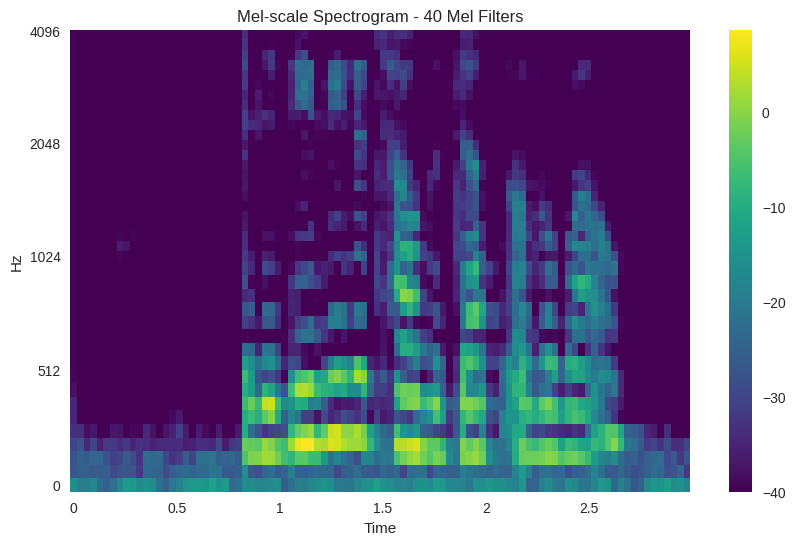

In [ ]:
n_mels = 40
n_fft_mel = int(2**np.ceil(np.log2(frame_length)))
X_mel = librosa.feature.melspectrogram(y=selected_segment, sr=sample_rate, n_mels=n_mels,
                                       n_fft=n_fft_mel, hop_length=hop_size, win_length=frame_length)

plt.figure(figsize=(10,6));
librosa.display.specshow(librosa.power_to_db(X_mel), sr=sample_rate, hop_length=hop_size, x_axis='time', y_axis='mel', fmax=sample_rate/2, cmap='viridis');
plt.clim(-40,None);
plt.colorbar();
plt.title('Mel-scale Spectrogram - 40 Mel Filters');

**Case 2 - Decreasing number of Mel bands to 10**

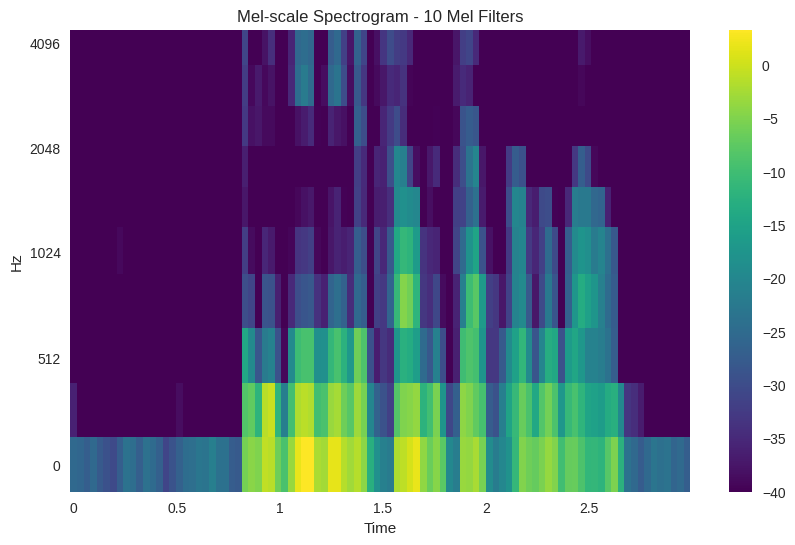

In [ ]:
n_mels_1 = n_mels/4;
X_mel = librosa.feature.melspectrogram(y=selected_segment, sr=sample_rate, n_mels=n_mels_1,
                                       n_fft=n_fft_mel, hop_length=hop_size, win_length=frame_length)

plt.figure(figsize=(10,6));
librosa.display.specshow(librosa.power_to_db(X_mel), sr=sample_rate, hop_length=hop_size, x_axis='time', y_axis='mel', fmax=sample_rate/2, cmap='viridis');
plt.clim(-40,None);
plt.colorbar();
plt.title('Mel-scale Spectrogram - 10 Mel Filters');

Conclusions: 40 Mel bands offer a much finer frequency resolution, in fact the  spectrogram has a more rich and detailed appearance; while with 10 Mel bands there is a a much coarser frequency resolution where each band covers a wider frequency range, visually the spectrogram appears more simplified and compressed.


### Now let's perform a similar analysis with a music signal ("oboe_c6.wav").


In [ ]:
# !wget -P sample_data/ https://ccrma.stanford.edu/workshops/dsp2008/sound-library/oboe/Oboe1/Oboe-C6.wav

oboeC6 , sr = librosa.load('./content/sample_data/Oboe-C6.wav', sr=None)
IPython.display.display(IPython.display.Audio(oboeC6, rate=sr))

/tmp/ipykernel_282/456539000.py:3: UserWarning: PySoundFile failed. Trying audioread instead.
  oboeC6 , sr = librosa.load('./content/sample_data/Oboe-C6.wav', sr=None)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


FileNotFoundError: [Errno 2] No such file or directory: './content/sample_data/Oboe-C6.wav'


**Case 1 - Setting number of Mel bands to be generated as 40**

In [ ]:
# Your code here!
# ...
# X_ob_mel = librosa.feature.melspectrogram(...
# ...
# plt.figure(figsize=(15,8));
# librosa.display.specshow(...

**Case 2 - Decreasing number of Mel bands to 10**

In [ ]:
# Your code here!

* Oboe analysis:

WRITE YOUR CONCLUSIONS HERE!

### **Exercise 6**: Constant-Q Transform

Let's first check the librosa documentation: https://librosa.org/doc/main/generated/librosa.cqt.html

The most important parameters are
  - **y** - audio sample vector ($x$)
  - **sr** - sampling rate of the audio signal (in Hz)
  - **hop_length** - see above (STFT)
  - **f_min** - minimum frequency (we can use the default value of 32.70 Hz which corresponds to the note C1)
  - **n_bins** - total number of frequency bins (e.g., for a frequency resolution of one bin per semitone and 4 octaves, this would be 4 * 12 = 48)
  - **bins_per_octave** - Logarithmic frequency resolution (frequency bins per octave, commonly: 12 or 36)
  - **tuning** - Tuning offset (can be used if known tuning frequency of an audio recording deviates from 440 Hz)

HINTS:

```Num of Octaves = n_bins / bins_per_octave```

```Max Frequency = fmin * 2**() n_bins / bins_per_octave```
  

### Tasks:
* Compute the constant Q transform using librosa.
Experiment with different values of the parameters and discuss the results.

**Case 1 - The default librosa.display.specshow parameter values.**

In [ ]:
# Add your code here!
# x, sr = librosa.load(...
# C = librosa.cqt(...
# logC = librosa.amplitude_to_db(
plt.figure(figsize=(15,8));
librosa.display.specshow(logC, sr=sr, x_axis='time', y_axis='cqt_note', cmap='viridis');
plt.xlabel('Time [s]');
plt.title('Constant-Q Transform Power Specturm');

**Case 2 - Limit the frequency range (fmin=Hz(C5)) -  increasing `bins_per_octave` to 24 **

In [ ]:
# Your code here
# fmin=librosa.note_to_hz('C5')
# ...

**Case 3 - Limit the frequency range (fmin=Hz(C5))- decrease the `n_bins` to 53 **

In [ ]:
# Your code here
# fmin=librosa.note_to_hz('C5')
# ...

* CQT Analysis

WRITE YOUR CONCLUSIONS HERE!

### **Exercise 7**: MFCCs

Let's first check the librosa documentation: https://librosa.org/doc/latest/generated/librosa.feature.mfcc.html#librosa.feature.mfcc

The most important parameters are
  - **y** - audio sample vector ($x$)
  - **sr** - sampling rate of the audio signal (in Hz)
  - **n_fft** - see above (STFT)
  - **hop_length** - see above (STFT)
  - **n_mfcc** - Number of MFC coefficients  

### Tasks:
* Compute MFCCs using librosa. Experiment with different values of the parameters and discuss the results.

**Case 1 - Using the standard librosa.feature.mfcc function on the audio file OSR_us_000_0010_8k.wav (seconds 7 to 10)**

In [ ]:
# Add your code here!
# signal, sample_rate = librosa.load(...
# ...

plt.figure(figsize=(15,8));
librosa.display.specshow(X_mfcc, sr=sample_rate, hop_length=hop_length, x_axis='time', cmap='viridis');
plt.clim(-40,None);
plt.colorbar();
plt.xlabel('Time [s]');
plt.ylabel('MFCC Coefficient');

**Case 2 - Increasing the number of components to 40**



In [ ]:
# Add your code here!
# num_ceps =40
# ...

* WRITE YOUR CONCLUSIONS HERE!

**Case 3 - Changing the coefficient weighting parameter `lifter` to the number of 2 x number of cepstral coefficients**


In [ ]:
# Add your code here!
# num_ceps = 40
# lifter = 2*num_ceps

* WRITE YOUR CONCLUSIONS HERE!

**Case 4 - Comparing the oboe_c6.wav audio and simple_piano.wav sound**

In [ ]:
# !wget -P sample_data/ https://ccrma.stanford.edu/workshops/dsp2008/sound-library/piano/YamahaH/YamahaH-C6.wav
# Add your code here!
# ...

* WRITE YOUR CONCLUSIONS HERE!